# UniVector — Python quickstart

`univector` is a Cython extension over the UniVector C ABI, shipped as a
self-contained wheel: the native library travels inside the package, so
installing it needs neither Nim nor a compiler.

```
pip install lituus-univector
```

## The API

In [1]:
import univector

univector.version(), univector.__version__, univector.abi_version()

('1.1.0', '1.1.0', 1)

## Building a path

A `Path` is a sequence of commands, built with the usual pen moves or with the
shape helpers. `to_d()` writes the SVG path data back out, and `Path.parse_d`
reads it in.

In [2]:
from univector import Path

p = Path()
p.move_to(10, 10)
p.line_to(90, 10)
p.line_to(90, 90)
p.close_path()

print("commands =", p.commands)
print("to_d     =", p.to_d())
print("bounds   =", p.bounds())

commands = [(1, (10.0, 10.0)), (2, (90.0, 10.0)), (2, (90.0, 90.0)), (0, ())]
to_d     = M 10 10 L 90 10 L 90 90 Z
bounds   = (10.0, 10.0, 80.0, 80.0)


## Bounds follow the curve, not its controls

A cubic's control points pull the curve without being on it. Here both controls
sit at `y = 40`, and the curve reaches exactly `30` — three quarters of the
control height, which is what the Bernstein weights come to at the midpoint.

In [3]:
curve = Path.parse_d("M 0 0 C 20 40 60 40 80 0 Z")

print("round trip  =", curve.to_d())
print("bounds      =", curve.bounds())
print("midpoint    =", univector.cubic_point((0, 0), (20, 40), (60, 40), (80, 0), 0.5))

round trip  = M 0 0 C 20 40 60 40 80 0 Z
bounds      = (0.0, 0.0, 80.0, 30.0)
midpoint    = (40.0, 30.0)


## Flattening trades points for fidelity

`flatten(tolerance)` replaces curves with line segments no further from the true
curve than the tolerance allows. A tighter tolerance costs more points.

In [4]:
for tolerance in (1.0, 0.25, 0.05):
    print(f"tolerance {tolerance:<5} -> {len(curve.flatten(tolerance))} points")

tolerance 1.0   -> 9 points
tolerance 0.25  -> 17 points
tolerance 0.05  -> 33 points


## Prepared geometry

`prepare()` flattens once and keeps the result, so stroking and tessellating the
same shape do not repeat the work. The snapshot is immutable: editing the path
afterwards leaves it untouched.

In [5]:
rect = Path()
rect.rect(10, 10, 60, 40)
prepared = rect.prepare(0.25)

print("segments  =", len(prepared))
print("tolerance =", prepared.tolerance)
print("bounds    =", prepared.bounds)

moving = Path()
moving.rect(0, 0, 10, 10)
snapshot = moving.prepare(0.25)
moving.line_to(200, 200)
print("its source path grew, the snapshot still has", len(snapshot), "segments")

segments  = 4
tolerance = 0.25
bounds    = (10.0, 10.0, 60.0, 40.0)
its source path grew, the snapshot still has 4 segments


## Stroking

`stroke(width)` returns the outline of the stroke as a new path. A stroke of
width 4 reaches half its width beyond the shape on each side, so the 60x40
rectangle grows to 64x44 and its origin moves back by 2.

In [6]:
outline = prepared.stroke(4.0)

print("rect bounds    =", prepared.bounds)
print("outline bounds =", outline.bounds())

rect bounds    = (10.0, 10.0, 60.0, 40.0)
outline bounds = (8.0, 8.0, 64.0, 44.0)


## Tessellation

`tessellate_fill` turns the prepared geometry into triangles for a GPU, indexed
rather than duplicated.

In [7]:
mesh = prepared.tessellate_fill()

print("vertices  =", len(mesh.vertices))
print("indices   =", len(mesh.indices))
print("triangles =", mesh.triangle_count)

vertices  = 4
indices   = 6
triangles = 2


## Colors are parsed or built, never constructed

`Color` has no public constructor: `Color.rgba` takes straight-alpha floats in
`[0, 1]`, and `Color.parse` reads a CSS Color 4 string.

In [8]:
from univector import Color

print("rgba  =", Color.rgba(1.0, 0.5, 0.0).to_svg())
print("hex   =", Color.parse("#ff8800").to_svg())
print("oklch =", Color.parse("oklch(70% 0.15 45)").to_svg())

try:
    Color(255, 128, 0)
except TypeError as exc:
    print("Color(...) ->", exc)

rgba  = #FF8000
hex   = #FF8800
oklch = #E97C48
Color(...) -> Color values are created by Color.rgba() or Color.parse()


## Rasterising, and the fill rule

`Image.fill` renders a path onto an RGBA8 surface. Where a shape crosses itself
the fill rule decides what counts as inside: `polygon` draws a convex pentagon,
where the two rules agree, but joining every second vertex of one traces a
pentagram, and its middle is enclosed twice. The non-zero rule keeps it, the
even-odd rule drops it.

In [9]:
import math

from univector import Image, WINDING_NON_ZERO, WINDING_EVEN_ODD

corners = [(32 + 28 * math.cos(math.radians(-90 + 72 * i)),
            32 + 28 * math.sin(math.radians(-90 + 72 * i))) for i in range(5)]

star = Path()
star.move_to(*corners[0])
for i in (2, 4, 1, 3):
    star.line_to(*corners[i])
star.close_path()

for name, rule in [("non-zero", WINDING_NON_ZERO), ("even-odd", WINDING_EVEN_ODD)]:
    img = Image(64, 64)
    img.fill(star, Color.rgba(1.0, 0.5, 0.0), winding=rule)
    centre = (32 * 64 + 32) * 4
    print(f"{name:9} centre pixel =", tuple(img.pixels()[centre:centre + 4]))

non-zero  centre pixel = (255, 128, 0, 255)
even-odd  centre pixel = (0, 0, 0, 0)


The rendered surface, as PNG bytes the notebook hands to the browser:

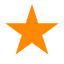

In [10]:
from IPython.display import Image as Show

img = Image(64, 64)
img.fill(star, Color.parse("#ff8800"))
Show(data=img.encode_png(), format="png")

## Markers

`markers_path` stamps one shape at every point in a sequence, which is how a
plotting library draws a scatter without building a path per point.

In [11]:
points = [(0.0, 0.0), (10.0, 5.0), (20.0, 0.0), (30.0, 5.0)]
stamped = univector.markers_path(univector.MARKER_CIRCLE, points, 4.0)

print("commands for", len(points), "markers =", len(stamped.commands))
print("bounds =", stamped.bounds())

commands for 4 markers = 24
bounds = (-2.0, -2.0, 34.0, 9.0)
